# Toronto 311 Requests Project

## Import Libraries

In [2]:
# Data Manipulation
import numpy as np
import pandas as pd

# Statistical Analysis
from scipy.stats import pearsonr

# Data Visualization
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
import geopandas as gpd

# Data modeling and evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Model Saving and Loading
import joblib

# Operating System
import os

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Data Loading

Critical information

- ward profile dosyasi incelendi bu dosya direkt ele alinacak dosya degil.
- burda istedigim bolum bize lazim. dosyanin icinde 'Income and shelter costs' bolumune gidip orde average ve median cost bolumunden median fiyat bilgileri biizm icin daha onemli.
- cunku outliera karsi daha iyi bir davaranis gostermis oluruz.
- "5 records (0.002% of the dataset) were excluded due to malformed rows in the source CSV, likely caused by inconsistent comma usage in the Section field for a small number of 'Transfer Station Odour Complaint' entries."

In [3]:
ward_list = []

for i in range(1, 26):
    ward_list.append(f'Ward {i}')

In [4]:
median_costs = [81000, 100000, 90000, 85000, 72000, 82000, 73000, 97000, 85000, 89000, 84000, 86000, 65000, 93000, 102000, 78500, 84000, 81000, 89000, 79000, 78000, 77000, 87000, 78000, 105000]

In [5]:
data_wards = pd.DataFrame({'Ward': ward_list, 'Median Cost': median_costs})

In [6]:
file_dir = 'C:\\Users\\Casper\\Desktop\\VS-CODE\\DataScienceProjects\\toronto_311_project\\data\\311_Service_Requests_2021.zip_unzipped\\SR2021.csv'

data_311_requests = pd.read_csv(
    file_dir,
    on_bad_lines='skip')

In [7]:
# Data Overview for 311 Service Requests
data_311_requests.head()

,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section
0,2021-01-01 00:03:03.0000000,Closed,M2J,,,Don Valley North (17),Zoning ...,Municipal Licensing & Standards,District Enforcement
1,2021-01-01 00:08:02.0000000,Closed,M4B,,,Beaches-East York (19),Zoning ...,Municipal Licensing & Standards,District Enforcement
2,2021-01-01 00:09:00.0000000,Closed,M4R,,,Eglinton-Lawrence (08),Res / Organic Bin / Additional ...,Solid Waste Management Services,Collections
3,2021-01-01 00:10:24.0000000,Closed,M5E,,,Spadina-Fort York (10),Zoning ...,Municipal Licensing & Standards,District Enforcement
4,2021-01-01 00:17:49.0000000,Closed,M8Y,,,Etobicoke-Lakeshore (03),Zoning ...,Municipal Licensing & Standards,District Enforcement


In [8]:
# Data Overview for wards and their median costs
data_wards.head()

,Ward,Median Cost
0,Ward 1,81000
1,Ward 2,100000
2,Ward 3,90000
3,Ward 4,85000
4,Ward 5,72000


## EDA

### Wards Dataset

In [9]:
data_wards.shape

(25, 2)

In [10]:
data_wards.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Ward         25 non-null     str  
 1   Median Cost  25 non-null     int64
dtypes: int64(1), str(1)
memory usage: 532.0 bytes


In [11]:
data_wards.describe()

,Median Cost
count,25.000000
mean,84820.000000
std,9529.428105
min,65000.000000
25%,78500.000000
50%,84000.000000
75%,89000.000000
max,105000.000000


### 311 Requests Dataset

In [12]:
data_311_requests.info()

<class 'pandas.DataFrame'>
RangeIndex: 323880 entries, 0 to 323879
Data columns (total 9 columns):
 #   Column                                                           Non-Null Count   Dtype
---  ------                                                           --------------   -----
 0   Creation Date                                                    323880 non-null  str  
 1    Status                                                          323880 non-null  str  
 2    First 3 Chars of Postal Code                                    323880 non-null  str  
 3    Intersection Street 1                                           323880 non-null  str  
 4    Intersection Street 2                                           323880 non-null  str  
 5    Ward                                                            323880 non-null  str  
 6    Service Request Type                                            323880 non-null  str  
 7    Division                                                  

In [13]:
data_311_requests.describe()

,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section
count,323880,323880,323880,323880,323880,323880,323880,323880,323880
unique,319884,6,101,4083,3848,26,476,8,20
top,2021-01-12 19:07:00.0000000,Closed,Intersection,,,Etobicoke-Lakeshore (03),Residential: Bin: Repair or Replace Lid ...,Solid Waste Management Services,Collections
freq,5,242934,34875,289005,289122,19787,14395,133950,133092


In [14]:
data_311_requests.columns

Index(['Creation Date              ', ' Status     ',
       ' First 3 Chars of Postal Code', ' Intersection Street 1           ',
       ' Intersection Street 2              ',
       ' Ward                         ',
       ' Service Request Type                                          ',
       ' Division                       ', ' Section'],
      dtype='str')

In [15]:
# Remove leading and trailing whitespace characters from column names
data_311_requests.columns = data_311_requests.columns.str.strip()

In [16]:
# Date Conversion: Convert the 'Creation Date' column to datetime format for easier analysis and manipulation of date-related data.
data_311_requests['Creation Date'] = pd.to_datetime(data_311_requests['Creation Date'])

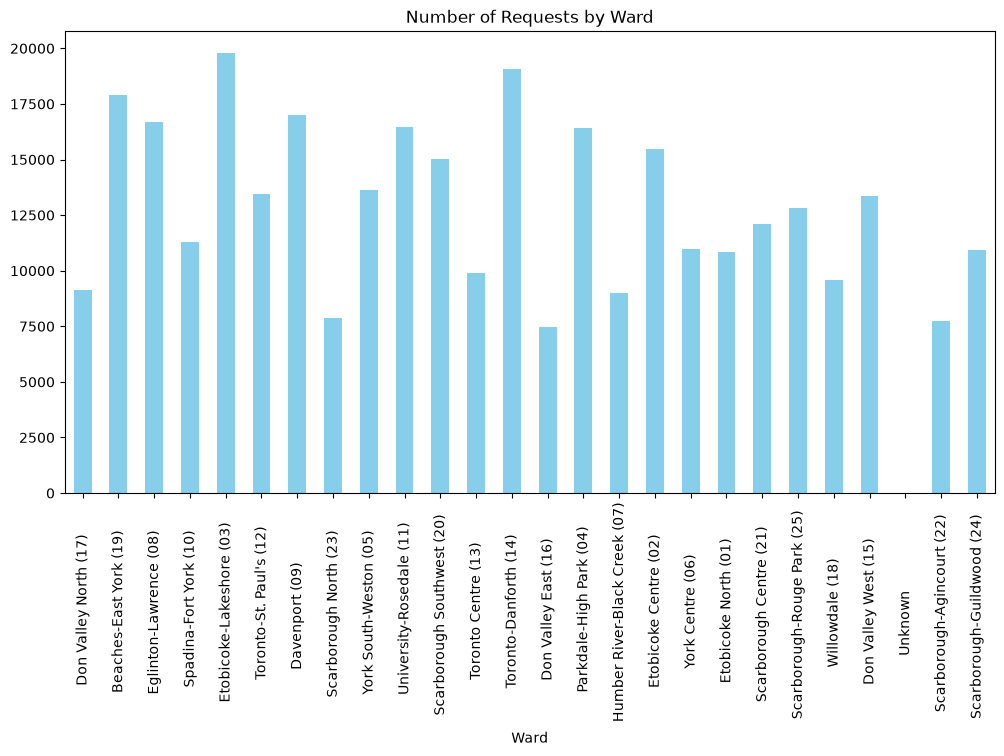

In [17]:
# Looking at the number of requests by ward
data_311_requests['Ward'].value_counts(sort=False).plot(kind='bar', figsize=(12, 6), title='Number of Requests by Ward', color='skyblue');

In [18]:
data_311_requests = data_311_requests[data_311_requests['Ward'].str.contains(r'\(', na=False)]

In [19]:
# splitting the 'Ward' column to extract the ward number and remove any leading/trailing whitespace and parentheses. This will help in cleaning the dataset and focusing on valid ward data.
data_311_requests['Ward'] = (
    data_311_requests['Ward']
    .str.split('(').str[1]      
    .str.strip()                
    .str.rstrip(')')             
    .astype(int)                 
    .apply(lambda x: f'Ward {x}')  
)

In [20]:
# Dropping unnecessary columns 'Intersection Street 1' and 'Intersection Street 2' from the dataset to streamline the data for analysis.
data_311_requests = data_311_requests.drop(columns=['Intersection Street 1', 'Intersection Street 2'])

### Mapping

In [23]:
data = data_311_requests.merge(data_wards, on='Ward', how='left')

<Axes: >

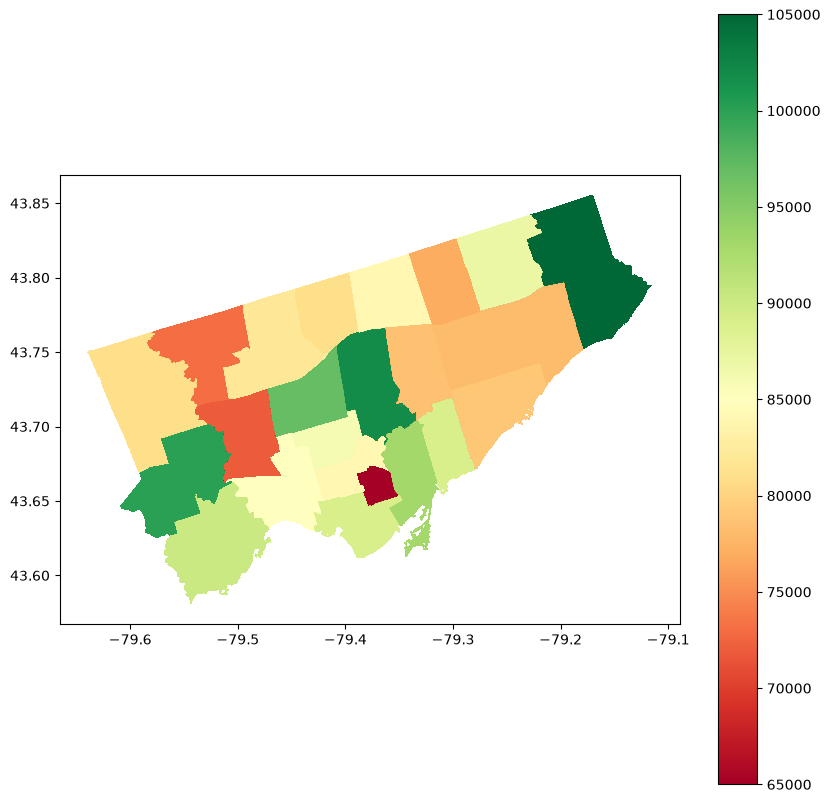

In [ ]:
wards_map = gpd.read_file('C:\\Users\\Casper\\Desktop\\VS-CODE\\DataScienceProjects\\toronto_311_project\\data\\City Wards Data - 4326.geojson')
wards_map['ward'] = wards_map['AREA_SHORT_CODE'].astype(int).apply(lambda x: f'Ward {x}')
# Merging the wards_map GeoDataFrame with the data DataFrame on the 'AREA_NAME' and 'Ward' columns to combine geographic information with the 311 service request data.
merged = wards_map.merge(data, left_on='ward', right_on='Ward')
merged.plot(column='Median Cost', cmap='RdYlGn', legend=True, figsize=(10,10))

### Visualisation Section

In [25]:
# Cleaning the 'Status' column by removing leading/trailing whitespace and standardizing the text to title case to ensure consistency in the dataset.
data['Status'] = data['Status'].str.strip().str.title()
print(data['Status'].unique())

<StringArray>
['Closed', 'Cancelled', 'Initiated', 'In-Progress', 'Unknown']
Length: 5, dtype: str


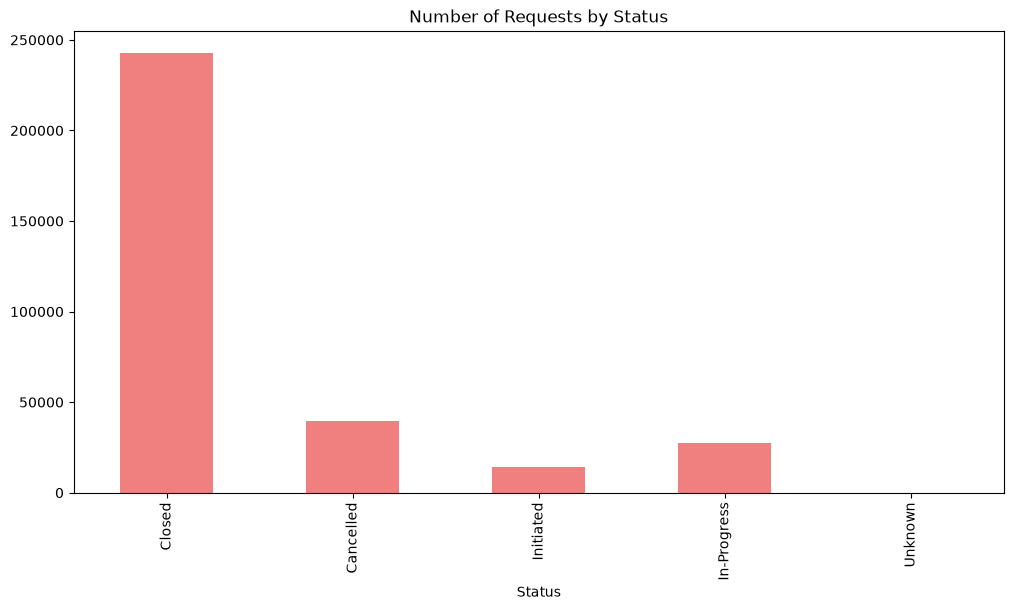

In [26]:
data['Status'].value_counts(sort=False).plot(kind='bar', figsize=(12, 6), title='Number of Requests by Status', color='lightcoral');

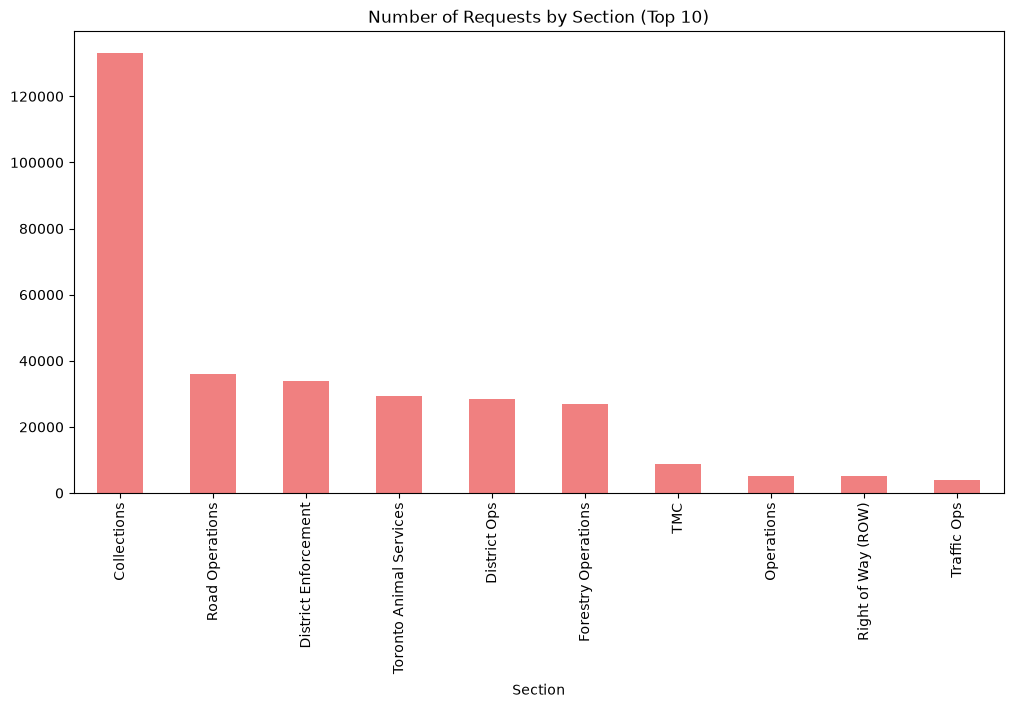

In [27]:
# Number of Requests by Section for the top 10 sections in the dataset, visualized using a bar chart to understand which sections have the highest number of service requests.
data['Section'].value_counts(sort=True).head(10).plot(kind='bar', figsize=(12, 6), title='Number of Requests by Section (Top 10)', color='lightcoral');

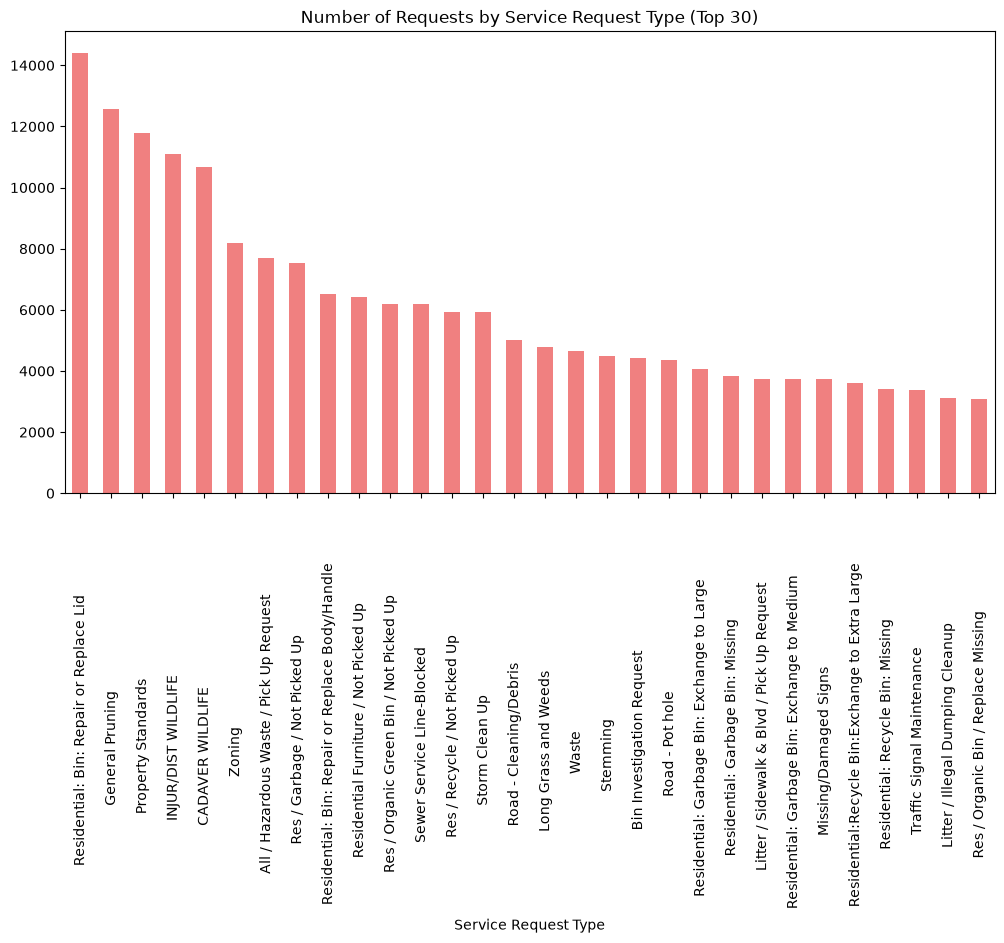

In [28]:
data['Service Request Type'].value_counts(sort=True).head(30).plot(kind='bar', figsize=(12, 6), title='Number of Requests by Service Request Type (Top 30)', color='lightcoral');

In [29]:
closure_summary = (
    data.groupby('Ward')['Status']
    .apply(lambda x: round((x == 'Closed').mean() * 100, 2))
    .reset_index()
)
closure_summary.columns = ['Ward', 'pct_closed']
print(closure_summary.sort_values('pct_closed'))

       Ward  pct_closed
6   Ward 15       63.96
10  Ward 19       66.85
8   Ward 17       67.37
5   Ward 14       68.31
9   Ward 18       71.06
7   Ward 16       71.34
17  Ward 25       72.00
12  Ward 20       73.84
15  Ward 23       74.25
4   Ward 13       74.38
16  Ward 24       75.13
2   Ward 11       75.31
14  Ward 22       75.83
3   Ward 12       76.38
11   Ward 2       76.58
13  Ward 21       77.23
23   Ward 8       77.75
0    Ward 1       78.55
24   Ward 9       78.73
18   Ward 3       78.99
19   Ward 4       79.02
21   Ward 6       79.86
22   Ward 7       79.96
1   Ward 10       80.77
20   Ward 5       81.43


In [30]:
# Checking the column names of the data_wards DataFrame to ensure they match the expected format for merging with the closure_summary DataFrame.
print(data_wards.columns.tolist())

# Merging the closure_summary DataFrame with the data_wards DataFrame on the 'Ward' column to combine the percentage of closed requests with the median cost data for each ward.
merged_summary = closure_summary.merge(data_wards, on='Ward', how='inner')
print(merged_summary.shape)          # shape should be (25, 3) since there are 25 wards and we have 3 columns: 'Ward', 'pct_closed', and 'Median Cost'
print(merged_summary.isna().sum())   # all should be 0

['Ward', 'Median Cost']
(25, 3)
Ward           0
pct_closed     0
Median Cost    0
dtype: int64


In [ ]:
corr, p_value = pearsonr(merged_summary['Median Cost'], merged_summary['pct_closed'])
print(f"Correlation coefficient (r): {corr:.3f}")
print(f"P-value: {p_value:.4f}")

Korelasyon katsayısı (r): -0.338
P-değeri: 0.0989


- A weak negative correlation was observed between median household income and 311 request closure rate (r = -0.338, p = 0.099), suggesting a possible trend where wealthier wards do not necessarily see higher closure rates. However, this result did not reach conventional statistical significance (p < 0.05), which may be attributable to the small sample size (n = 25 wards) limiting statistical power.

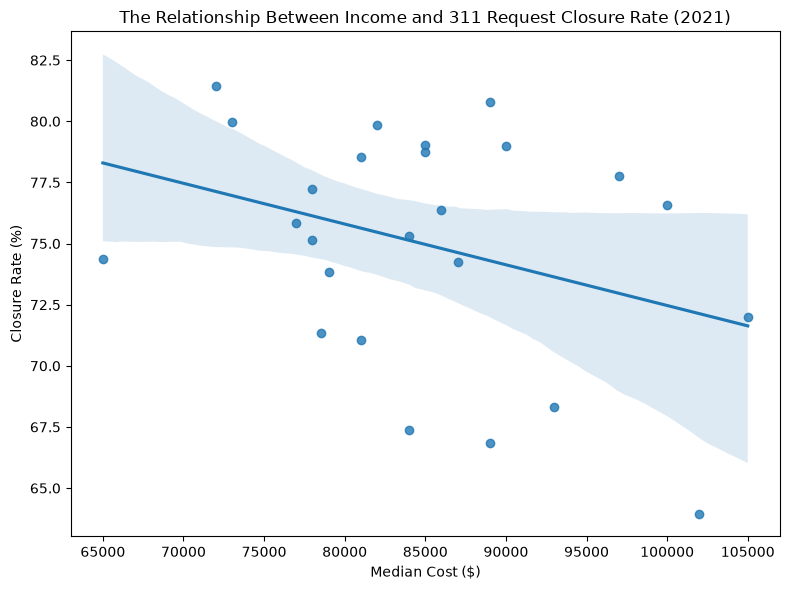

In [32]:
plt.figure(figsize=(8,6))
sns.regplot(data=merged_summary, x='Median Cost', y='pct_closed')
plt.xlabel('Median Cost ($)')
plt.ylabel('Closure Rate (%)')
plt.title('The Relationship Between Income and 311 Request Closure Rate (2021)')
plt.tight_layout()
plt.savefig('income_vs_closure_rate.png', dpi=150)
plt.show()

In [33]:
# Choose only sufficiently common request types (e.g., at least 400 records in total) to focus the analysis on the most relevant service request types and avoid noise from less frequent requests.
type_counts = data['Service Request Type'].value_counts()
common_types = type_counts[type_counts >= 400].index.tolist()
print(f"{len(common_types)} sufficiently common request types found")

131 sufficiently common request types found


In [ ]:
results = []

for req_type in common_types:
    subset = data[data['Service Request Type'] == req_type]
    
    # Calculate the closure rate for each ward for the current service request type, which will help in understanding how different wards perform in terms of closing requests of this type.
    type_closure = (
        subset.groupby('Ward')['Status']
        .apply(lambda x: (x == 'Closed').mean() * 100)
        .reset_index()
    )
    type_closure.columns = ['Ward', 'pct_closed']
    
    # Merging the closure rate data for the current service request type with the median cost data for each ward to analyze the relationship between income and closure rates for this specific request type.
    type_merged = type_closure.merge(data_wards, on='Ward', how='inner')
    
    # Only consider service request types that have data for at least 15 wards to ensure that the correlation analysis is meaningful and statistically significant.
    if len(type_merged) >= 15:
        corr, p_val = pearsonr(type_merged['Median Cost'], type_merged['pct_closed'])
        results.append({
            'Service Request Type': req_type,
            'n_requests': len(subset),
            'n_wards': len(type_merged),
            'correlation': corr,
            'p_value': p_val
        })

results_df = pd.DataFrame(results).sort_values('p_value')

In [35]:
results_df[results_df['p_value'] < 0.05].sort_values('correlation', ascending=False)

,Service Request Type,n_requests,n_wards,correlation,p_value
53,Res / Organic Bin / Additional ...,1439,25,0.515576,0.008344
54,Water Service Line-Low Pressure|| Low Flow Ap...,1437,25,0.450759,0.023736
28,Litter / Illegal Dumping Cleanup ...,3113,25,0.449246,0.024268
0,Residential: Bin: Repair or Replace Lid ...,14395,25,0.439431,0.027959
49,Tree Planting ...,1582,25,0.423479,0.034909
81,Multi-Res / Garbage Front-End / Not Picked Up...,780,25,-0.413311,0.040013
107,Catch Basin - Debris / Litter ...,529,25,-0.435994,0.029354
19,Road - Pot hole ...,4356,25,-0.438091,0.028496
128,Boulevards - Weed Removal ...,410,25,-0.439452,0.027951
37,Residential: Recycle Bin: Additional Extra La...,2318,25,-0.491413,0.012606


Group 1: Higher closure rates in high-income wards (positive correlation)
- Res / Organic Bin / Additional (r=0.52, p=0.008) — the strongest relationship 
- Water Service Line - Low Pressure (r=0.45, p=0.024)
- Litter / Illegal Dumping Cleanup (r=0.45, p=0.024)
- Bin: Repair or Replace Lid (r=0.44, p=0.028)
- Tree Planting (r=0.42, p=0.035)

Group 2: Lower closure rates in low-income wards (negative correlation)
- Recycle Bin: Additional Extra Large (r=-0.49, p=0.013)
- Road - Pot hole (r=-0.44, p=0.028)
- Boulevards - Weed Removal (r=-0.44, p=0.028)
- Catch Basin - Debris/Litter (r=-0.44, p=0.029)
- Multi-Res / Garbage Front-End Not Picked Up (r=-0.41, p=0.040)

Note: 
- While the overall correlation between median household income and 311 closure rate across all request types was weak and not statistically significant (r = -0.338, p = 0.099), a request-type-level breakdown revealed a more nuanced pattern. Ten service categories showed statistically significant correlations (p < 0.05) with ward income. Notably, requests related to quality-of-life amenities (e.g., organic bin additions, tree planting) showed positive correlations with income, while requests related to core infrastructure maintenance and multi-residential services (e.g., pothole repair, garbage pickup) showed negative correlations. This suggests the relationship between income and service responsiveness in Toronto may be category-dependent rather than uniform, warranting further investigation with additional controls (e.g., population density, request volume, housing type). It should be noted that with 10 categories tested, some significant results may reflect multiple-comparisons noise rather than a true effect.

In [36]:
data['Month'] = data['Creation Date'].dt.month

monthly_counts = data.groupby('Month').size().reset_index(name='request_count')

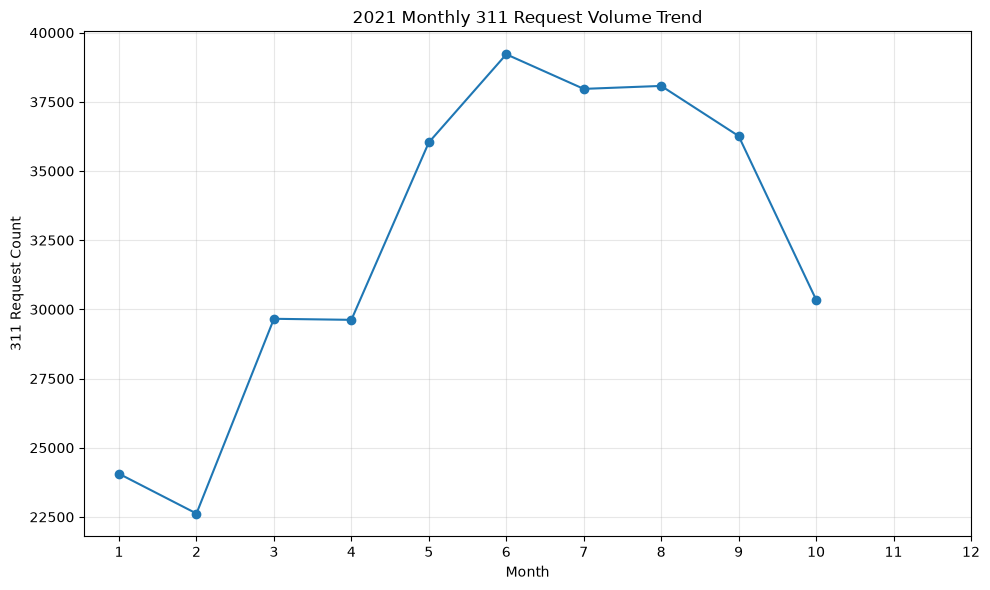

In [37]:
plt.figure(figsize=(10,6))
plt.plot(monthly_counts['Month'], monthly_counts['request_count'], marker='o')
plt.xlabel('Month')
plt.ylabel('311 Request Count')
plt.title('2021 Monthly 311 Request Volume Trend')
plt.xticks(range(1,13))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150)
plt.show()

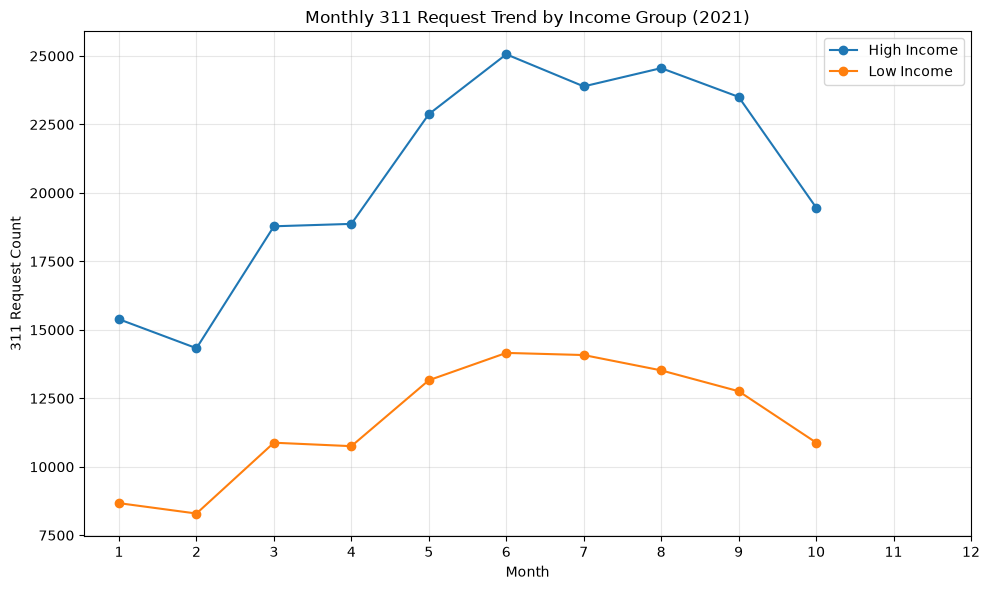

In [38]:
# Classify wards based on median income
median_income_overall = data_wards['Median Cost'].median()
data_wards['income_group'] = data_wards['Median Cost'].apply(
    lambda x: 'High Income' if x >= median_income_overall else 'Low Income'
)

# Merge the income group information with the main data to analyze trends based on income groups.
data_with_group = data.merge(data_wards[['Ward', 'income_group']], on='Ward', how='left')

# Group by month and income group to count the number of requests in each category, which will help in analyzing the trends of 311 requests based on income levels.
monthly_by_group = data_with_group.groupby(['Month', 'income_group']).size().reset_index(name='request_count')

# visualization
plt.figure(figsize=(10,6))
for group in ['High Income', 'Low Income']:
    subset = monthly_by_group[monthly_by_group['income_group'] == group]
    plt.plot(subset['Month'], subset['request_count'], marker='o', label=group)

plt.xlabel('Month')
plt.ylabel('311 Request Count')
plt.title('Monthly 311 Request Trend by Income Group (2021)')
plt.xticks(range(1,13))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_trend_by_income.png', dpi=150)
plt.show()

In [39]:
# check the distribution of wards in each income group
print(data_wards['income_group'].value_counts())

# Calculate the average number of requests per ward in each income group - not the raw total
requests_per_ward_group = data_with_group.groupby(['Month', 'income_group']).size().reset_index(name='request_count')
ward_counts = data_wards['income_group'].value_counts()
requests_per_ward_group['requests_per_ward'] = requests_per_ward_group.apply(
    lambda row: row['request_count'] / ward_counts[row['income_group']], axis=1
)
print(requests_per_ward_group)

income_group
High Income    14
Low Income     11
Name: count, dtype: int64
    Month income_group  request_count  requests_per_ward
0       1  High Income          15387        1099.071429
1       1   Low Income           8672         788.363636
2       2  High Income          14329        1023.500000
3       2   Low Income           8293         753.909091
4       3  High Income          18781        1341.500000
5       3   Low Income          10879         989.000000
6       4  High Income          18869        1347.785714
7       4   Low Income          10753         977.545455
8       5  High Income          22875        1633.928571
9       5   Low Income          13160        1196.363636
10      6  High Income          25061        1790.071429
11      6   Low Income          14158        1287.090909
12      7  High Income          23889        1706.357143
13      7   Low Income          14080        1280.000000
14      8  High Income          24556        1754.000000
15      8   L

- Even after normalizing for the unequal number of wards per income group (14 high-income vs. 11 low-income), high-income wards consistently generated approximately 30-40% more 311 requests per ward across all months. This gap should not be interpreted as evidence that residents in wealthier areas experience more service issues; plausible alternative explanations include differences in digital access to the 311 platform, housing type (single-family vs. multi-unit), and rates of homeownership, which merits further investigation.

## Data Preparation

In [40]:
data['is_risky'] = (data['Status'] != 'Closed').astype(int)

In [41]:
model_df = data[['Ward', 'Service Request Type', 'Division', 'Month', 'Median Cost', 'is_risky']].copy()

In [42]:
le_ward = LabelEncoder()
le_type = LabelEncoder()
le_division = LabelEncoder()

In [43]:
model_df['Ward_enc'] = le_ward.fit_transform(model_df['Ward'])
model_df['Type_enc'] = le_type.fit_transform(model_df['Service Request Type'])
model_df['Division_enc'] = le_division.fit_transform(model_df['Division'])

In [44]:
model_df['Month_sin'] = np.sin(2 * np.pi * model_df['Month'] / 12)
model_df['Month_cos'] = np.cos(2 * np.pi * model_df['Month'] / 12)

## Train-Test Seperation Process 

In [45]:
X = model_df[['Ward_enc', 'Type_enc', 'Division_enc',  'Month_sin', 'Month_cos', 'Median Cost']]
y = model_df['is_risky']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Data Modeling

In [46]:
rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced', criterion = 'log_loss')
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.90      0.77      0.83     48587
           1       0.52      0.74      0.61     16189

    accuracy                           0.76     64776
   macro avg       0.71      0.75      0.72     64776
weighted avg       0.80      0.76      0.77     64776

ROC-AUC: 0.8383389095576619


In [47]:
lr = LogisticRegression(random_state=42, class_weight='balanced', max_iter=500)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_proba = lr.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.82      0.60      0.69     48587
           1       0.34      0.61      0.43     16189

    accuracy                           0.60     64776
   macro avg       0.58      0.61      0.56     64776
weighted avg       0.70      0.60      0.63     64776

ROC-AUC: 0.6427561772712101


## Feature Importance 

In [48]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

FileNotFoundError: [Errno 2] No such file or directory: 'images/feature_importance.png'

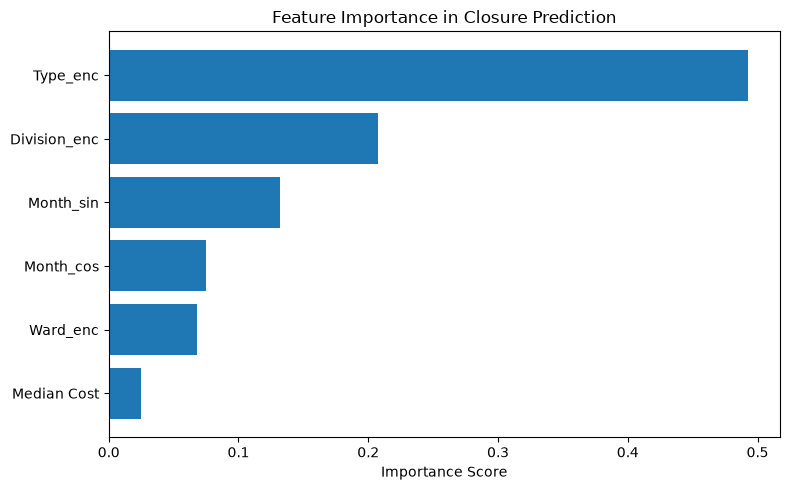

In [49]:
plt.figure(figsize=(8,5))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance Score')
plt.title('Feature Importance in Closure Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('images/feature_importance.png', dpi=150)
plt.show()

## Model Evaluation

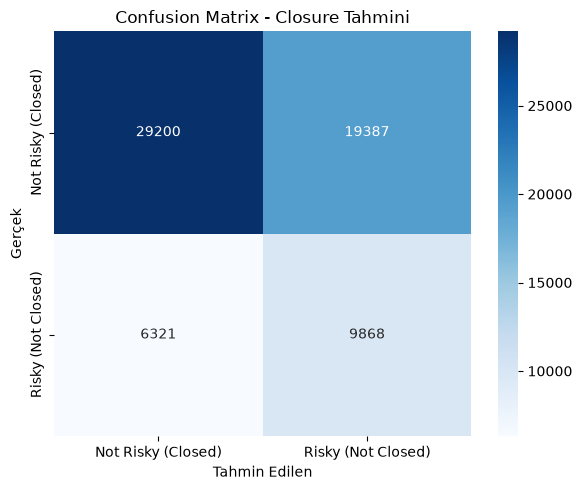

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Risky (Closed)', 'Risky (Not Closed)'],
            yticklabels=['Not Risky (Closed)', 'Risky (Not Closed)'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.title('Confusion Matrix - Closure Tahmini')
plt.tight_layout()
plt.savefig('images/confusion_matrix.png', dpi=150)
plt.show()

- Given the project's goal of proactively identifying requests at risk of remaining unresolved, the positive class was defined as 'Not Closed,' and model selection prioritized sensitivity (recall) over specificity to minimize the risk of failing to flag at-risk requests.

## Model Saving

In [ ]:
os.makedirs('models', exist_ok=True)

# We save the trained Random Forest model to a file named 'closure_risk_model.pkl' using joblib. This allows us to reuse the model later without retraining it.
joblib.dump(rf, 'models/closure_risk_model.pkl')

# Encoder has been saved to separate files for later use in transforming new data before making predictions with the saved model.
joblib.dump(le_ward, 'models/ward_encoder.pkl')
joblib.dump(le_type, 'models/type_encoder.pkl')
joblib.dump(le_division, 'models/division_encoder.pkl')

print("Model and encoders have been saved successfully.")

Model and encoders have been saved successfully.
